In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier as RB
#from sklearn.decomposition import KernelPCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE as SM
from sklearn.ensemble import RandomForestRegressor as RF,GradientBoostingRegressor as GB,ExtraTreesClassifier as ET
from sklearn.metrics import f1_score
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.neural_network import MLPClassifier as MP

In [2]:
df=pd.read_csv('data.csv')
df.columns = [c if '/' not in c else '/'.join([str(int(x)) for x in c.split('/')]) for c in df.columns]
print(df.columns[:6].tolist())

['CONS_NO', 'FLAG', '2014/1/1', '2014/1/10', '2014/1/11', '2014/1/12']


In [3]:
#df1=df[df["FLAG"]==0]

In [4]:
#df1=df
df.head()

,CONS_NO,FLAG,2014/1/1,2014/1/10,2014/1/11,2014/1/12,2014/1/13,2014/1/14,2014/1/15,2014/1/16,...,2016/9/28,2016/9/29,2016/9/3,2016/9/30,2016/9/4,2016/9/5,2016/9/6,2016/9/7,2016/9/8,2016/9/9
0,0387DD8A07E07FDA6271170F86AD9151,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.12,9.96,16.92,7.60,27.22,18.05,26.47,18.75,17.84,14.92
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B32AC8CC6D5D805AC053557AB05F5343,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.50,9.99,11.78,18.59,26.80,18.57,14.59,12.82,19.37,15.92
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.9,3.42,3.81,4.58,3.56,4.25,3.86,3.53,...,17.77,10.37,15.32,13.51,12.23,14.68,16.35,18.14,18.41,17.31


In [5]:
math.isnan(df.iloc[0][2])

C:\Users\shriy\AppData\Local\Temp\ipykernel_28008\936757609.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  math.isnan(df.iloc[0][2])


True

In [6]:
#df1.shape

In [7]:
#df.head(

In [8]:
#df1.isnull().sum()
l=df.columns
la=['CONS_NO','FLAG']
lb=[]
for i in l:
    if i not in la:
        lb.append(i)

In [9]:
import datetime
# Parse dates from lb (format: YYYY/M/D, no leading zeros)
dates = [datetime.datetime(int(ts.split("/")[0]), int(ts.split("/")[1]), int(ts.split("/")[2])) for ts in lb]
fdates = [f"{d.year}/{d.month}/{d.day}" for d in dates]


In [10]:
fdates.insert(0,"FLAG")
fdates.insert(0,"CONS_NO")


In [11]:
df.columns=fdates


In [12]:
import datetime
dates = [datetime.datetime(int(ts.split("/")[0]), int(ts.split("/")[1]), int(ts.split("/")[2])) for ts in lb]
dates.sort()
sorteddates = [f"{d.year}/{d.month}/{d.day}" for d in dates]


In [13]:
cols=df.columns.tolist()[0:2]+sorteddates
df=df[cols]

In [14]:
df

,CONS_NO,FLAG,2014/1/1,2014/1/2,2014/1/3,2014/1/4,2014/1/5,2014/1/6,2014/1/7,2014/1/8,...,2016/10/22,2016/10/23,2016/10/24,2016/10/25,2016/10/26,2016/10/27,2016/10/28,2016/10/29,2016/10/30,2016/10/31
0,0387DD8A07E07FDA6271170F86AD9151,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.18,8.07,8.09,9.53,5.48,8.75,9.30,7.54,9.16,6.74
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.95,17.95,17.83,17.31,21.44,19.09,18.56,16.25,14.20,13.66
3,B32AC8CC6D5D805AC053557AB05F5343,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.81,15.12,17.26,14.91,19.59,20.79,17.95,19.26,14.46,11.72
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.90,5.64,6.99,3.32,3.61,5.35,4.73,3.68,...,14.21,10.22,8.47,6.11,6.10,6.73,7.52,10.89,9.86,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42367,F1472871E1AFF49D4289564B6377D76C,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.27,3.10,2.75,3.01,2.99,2.83,2.54,3.40,3.59,2.54
42368,F3C8BBCD2DC26C1E0249DEEF6A4256B7,0,2.70,0.00,0.00,5.72,6.05,5.81,3.07,4.04,...,3.84,6.62,3.12,5.16,3.62,4.64,3.71,6.22,6.05,4.77
42369,A9A0FE83467A680FBFB0DBFC910DF227,0,0.58,1.16,0.92,0.98,1.54,1.38,0.89,0.70,...,0.99,0.61,0.65,0.55,0.49,0.51,0.79,0.66,0.39,0.65
42370,D9A6ADA018FA46A55D5438370456AA45,0,16.89,15.15,19.28,17.19,16.80,17.48,17.86,23.99,...,15.64,16.48,13.04,10.39,12.00,11.15,12.22,13.16,13.33,10.39


In [15]:
#df=df[cols]
df1=df

In [16]:
df1.columns = [c if '/' not in c else '/'.join([str(int(x)) for x in c.split('/')]) for c in df1.columns]

In [17]:
l=df[lb[0]]
l1=df[lb[1]]
l=np.asarray(l).tolist()
l1=np.asarray(l1).tolist()


# (removed)


# (removed)


In [18]:
# (removed)


In [19]:
l2=[]
for i in range(len(l)):
    if math.isnan(l[i]):
        if math.isnan(l1[i]):
            l2.append(0)
        else:
            l2.append(l1[i]/2)
    else:
        l2.append(l[i])
df1[lb[0]]=l2


In [20]:
df1.head()

,CONS_NO,FLAG,2014/1/1,2014/1/2,2014/1/3,2014/1/4,2014/1/5,2014/1/6,2014/1/7,2014/1/8,...,2016/10/22,2016/10/23,2016/10/24,2016/10/25,2016/10/26,2016/10/27,2016/10/28,2016/10/29,2016/10/30,2016/10/31
0,0387DD8A07E07FDA6271170F86AD9151,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.18,8.07,8.09,9.53,5.48,8.75,9.30,7.54,9.16,6.74
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.95,17.95,17.83,17.31,21.44,19.09,18.56,16.25,14.20,13.66
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.81,15.12,17.26,14.91,19.59,20.79,17.95,19.26,14.46,11.72
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.9,5.64,6.99,3.32,3.61,5.35,4.73,3.68,...,14.21,10.22,8.47,6.11,6.10,6.73,7.52,10.89,9.86,8.72


In [21]:
df.columns[-1],df.columns[-2]

('2016/10/31', '2016/10/30')

In [22]:
df.iloc[0][1035]

C:\Users\shriy\AppData\Local\Temp\ipykernel_28008\273509082.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][1035]


np.float64(6.74)

In [23]:
l=df[df.columns[-1]]
l1=df[df.columns[-2]]
l=np.asarray(l).tolist()
l1=np.asarray(l1).tolist()


In [24]:
l2=[]
for i in range(len(l)):
    if math.isnan(l[i]):
        if math.isnan(l1[i]):
            l2.append(0)
        else:
            l2.append(l1[i]/2)
    else:
        l2.append(l[i])
df1[df.columns[-1]]=l2


In [25]:
df1.head()

,CONS_NO,FLAG,2014/1/1,2014/1/2,2014/1/3,2014/1/4,2014/1/5,2014/1/6,2014/1/7,2014/1/8,...,2016/10/22,2016/10/23,2016/10/24,2016/10/25,2016/10/26,2016/10/27,2016/10/28,2016/10/29,2016/10/30,2016/10/31
0,0387DD8A07E07FDA6271170F86AD9151,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.18,8.07,8.09,9.53,5.48,8.75,9.30,7.54,9.16,6.74
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.95,17.95,17.83,17.31,21.44,19.09,18.56,16.25,14.20,13.66
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.81,15.12,17.26,14.91,19.59,20.79,17.95,19.26,14.46,11.72
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.9,5.64,6.99,3.32,3.61,5.35,4.73,3.68,...,14.21,10.22,8.47,6.11,6.10,6.73,7.52,10.89,9.86,8.72


In [26]:
#for i in range(42372):
#    l=np.asarray(df1[i:i+1]).tolist()[0]
#    l1=[]
#    l1[0:3]=l[0:3]
#    for j in range(3,1035):
#        if math.isnan(l[j]):
#            if math.isnan(l[j+1])==False and math.isnan(l[j-1])==False:
#                l1.append((l[j-1]+l[j+1])/2)
#            else:
#                l1.append(0)
#        else:
#            l1.append(l[j])
#    l1.append(l[-1])
#   df1[i:i+1]=l1

In [27]:
df.columns

Index(['CONS_NO', 'FLAG', '2014/1/1', '2014/1/2', '2014/1/3', '2014/1/4',
       '2014/1/5', '2014/1/6', '2014/1/7', '2014/1/8',
       ...
       '2016/10/22', '2016/10/23', '2016/10/24', '2016/10/25', '2016/10/26',
       '2016/10/27', '2016/10/28', '2016/10/29', '2016/10/30', '2016/10/31'],
      dtype='object', length=1036)

In [28]:
#df1.isnull().sum()
l=df.columns
la=['CONS_NO','FLAG']
lbx=[]
for i in l:
    if i not in la:
        lbx.append(i)

In [29]:
lb

['2014/1/1',
 '2014/1/10',
 '2014/1/11',
 '2014/1/12',
 '2014/1/13',
 '2014/1/14',
 '2014/1/15',
 '2014/1/16',
 '2014/1/17',
 '2014/1/18',
 '2014/1/19',
 '2014/1/2',
 '2014/1/20',
 '2014/1/21',
 '2014/1/22',
 '2014/1/23',
 '2014/1/24',
 '2014/1/25',
 '2014/1/26',
 '2014/1/27',
 '2014/1/28',
 '2014/1/29',
 '2014/1/3',
 '2014/1/30',
 '2014/1/31',
 '2014/1/4',
 '2014/1/5',
 '2014/1/6',
 '2014/1/7',
 '2014/1/8',
 '2014/1/9',
 '2014/10/1',
 '2014/10/10',
 '2014/10/11',
 '2014/10/12',
 '2014/10/13',
 '2014/10/14',
 '2014/10/15',
 '2014/10/16',
 '2014/10/17',
 '2014/10/18',
 '2014/10/19',
 '2014/10/2',
 '2014/10/20',
 '2014/10/21',
 '2014/10/22',
 '2014/10/23',
 '2014/10/24',
 '2014/10/25',
 '2014/10/26',
 '2014/10/27',
 '2014/10/28',
 '2014/10/29',
 '2014/10/3',
 '2014/10/30',
 '2014/10/31',
 '2014/10/4',
 '2014/10/5',
 '2014/10/6',
 '2014/10/7',
 '2014/10/8',
 '2014/10/9',
 '2014/11/1',
 '2014/11/10',
 '2014/11/11',
 '2014/11/12',
 '2014/11/13',
 '2014/11/14',
 '2014/11/15',
 '2014/11/16',


In [30]:
print(lb[:10])
print(len(lb))

['2014/1/1', '2014/1/10', '2014/1/11', '2014/1/12', '2014/1/13', '2014/1/14', '2014/1/15', '2014/1/16', '2014/1/17', '2014/1/18']
1034


In [31]:
print("lb first 10:", lb[:10])
print("df columns first 10:", df.columns[:10].tolist())

lb first 10: ['2014/1/1', '2014/1/10', '2014/1/11', '2014/1/12', '2014/1/13', '2014/1/14', '2014/1/15', '2014/1/16', '2014/1/17', '2014/1/18']
df columns first 10: ['CONS_NO', 'FLAG', '2014/1/1', '2014/1/2', '2014/1/3', '2014/1/4', '2014/1/5', '2014/1/6', '2014/1/7', '2014/1/8']


In [32]:
for i in range(1,len(lb)-1):
    l=np.asarray(df[lb[i]]).tolist()
    l1=np.asarray(df[lb[i-1]]).tolist()
    l2=np.asarray(df[lb[i+1]]).tolist()
    l3=[]
    for j in range(len(l)):
        if math.isnan(l[j]):
            if math.isnan(l1[j])==False and math.isnan(l2[j])==False:
                l3.append((l1[j]+l2[j])/2)
            else:
                l3.append(0)
        else:
            l3.append(l[j])
    df1[lb[i]]=l3

In [33]:
print(lb[:10])

['2014/1/1', '2014/1/10', '2014/1/11', '2014/1/12', '2014/1/13', '2014/1/14', '2014/1/15', '2014/1/16', '2014/1/17', '2014/1/18']


In [34]:
df1.head()

,CONS_NO,FLAG,2014/1/1,2014/1/2,2014/1/3,2014/1/4,2014/1/5,2014/1/6,2014/1/7,2014/1/8,...,2016/10/22,2016/10/23,2016/10/24,2016/10/25,2016/10/26,2016/10/27,2016/10/28,2016/10/29,2016/10/30,2016/10/31
0,0387DD8A07E07FDA6271170F86AD9151,1,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,7.18,8.07,8.09,9.53,5.48,8.75,9.30,7.54,9.16,6.74
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,10.95,17.95,17.83,17.31,21.44,19.09,18.56,16.25,14.20,13.66
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,12.81,15.12,17.26,14.91,19.59,20.79,17.95,19.26,14.46,11.72
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.9,5.64,6.99,3.32,3.61,5.35,4.73,3.68,...,14.21,10.22,8.47,6.11,6.10,6.73,7.52,10.89,9.86,8.72


In [35]:
#plt.scatter(df["2014/1/14"],df["FLAG"])

In [36]:
#df.isnull().sum(axis=1)
#df1.iloc[4].value_counts()

In [37]:
l1=lbx[100:990]

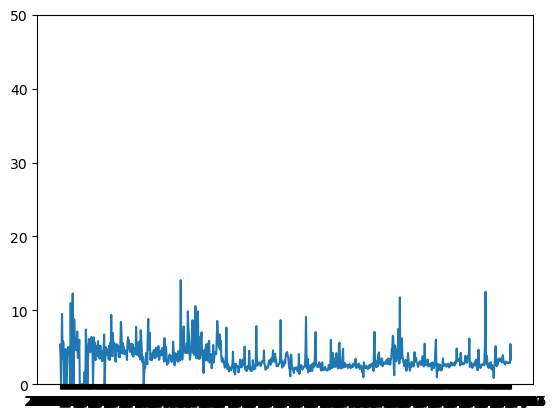

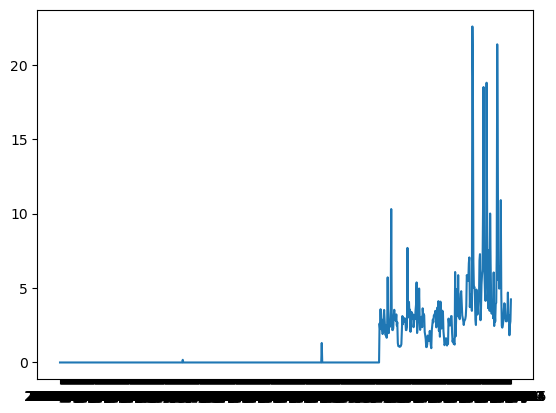

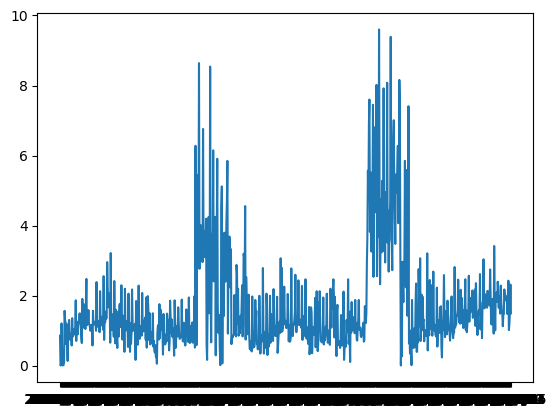

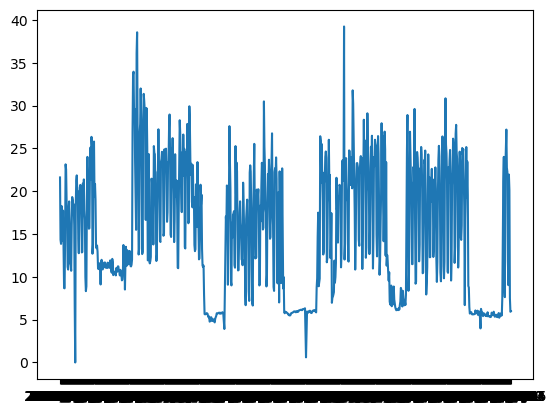

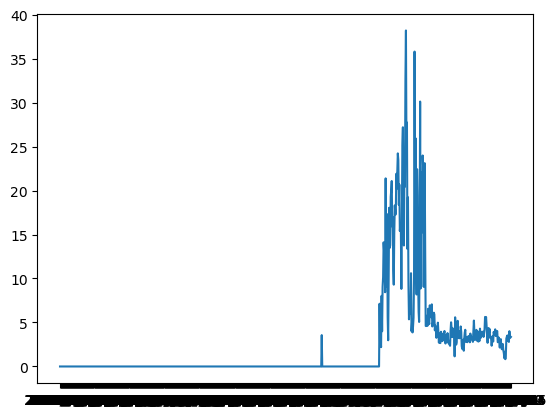

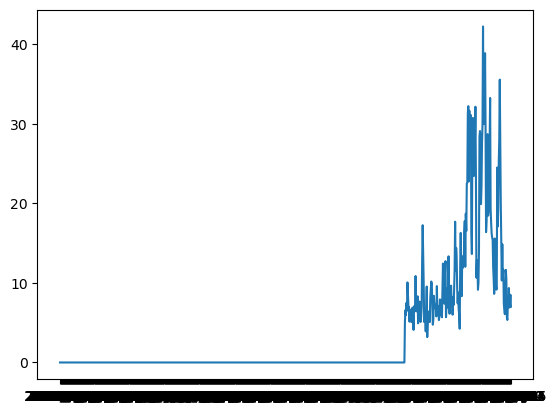

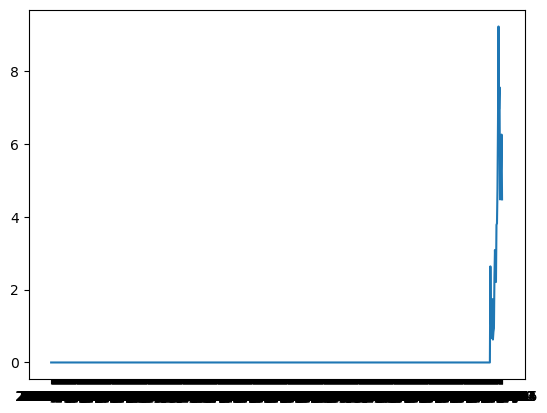

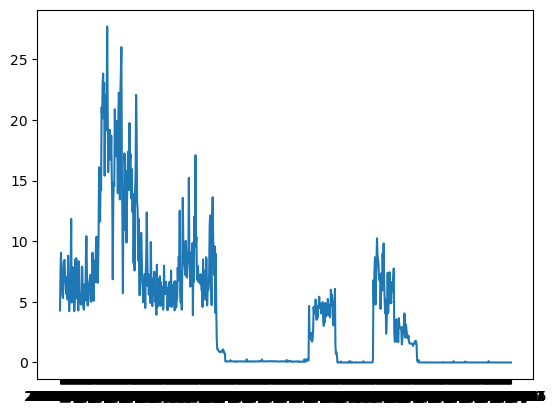

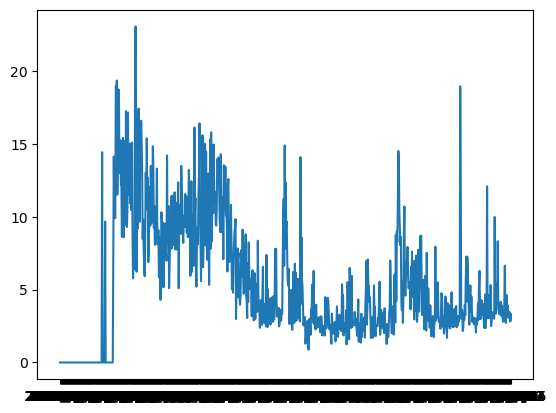

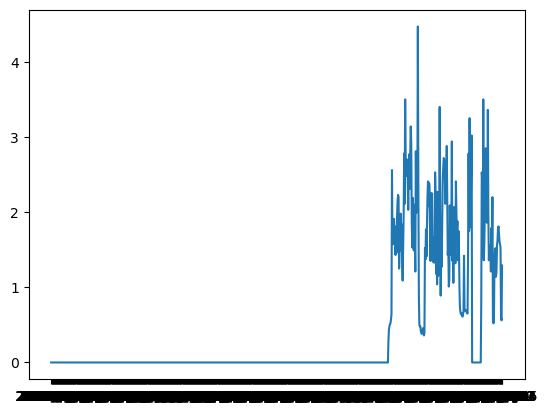

In [38]:
#4372,14,4919,4808,261 278 267 280 must
#major start from col 700 to last
#on whole a constancy should be maintained for not theft
axes = plt.gca()
#axes.set_xlim([,])
axes.set_ylim([0,50])
for i in range(5700,5710):
    plt.plot(l1,df1.iloc[i][l1])
    plt.show()

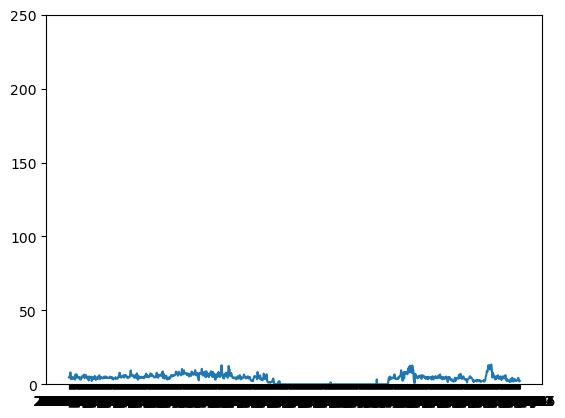

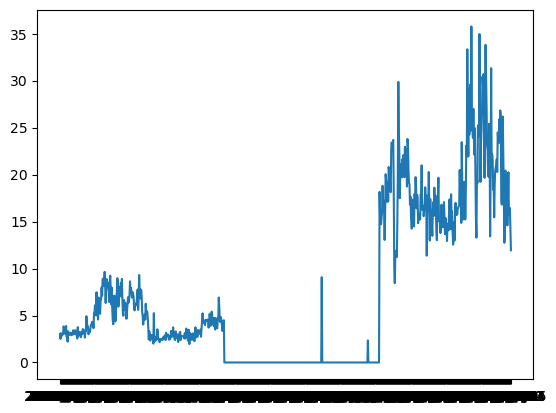

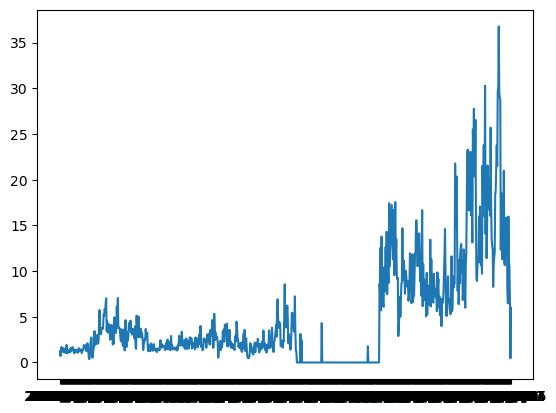

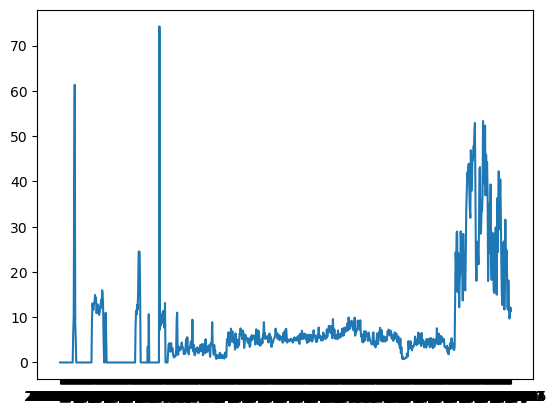

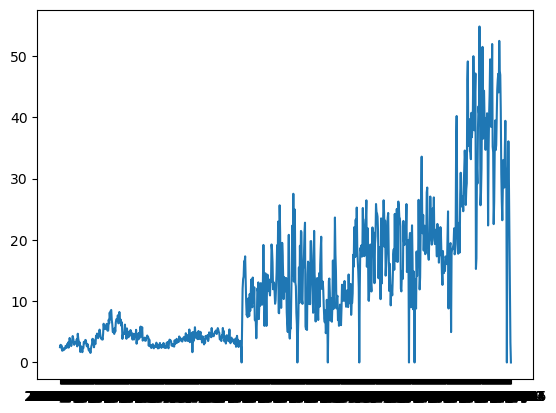

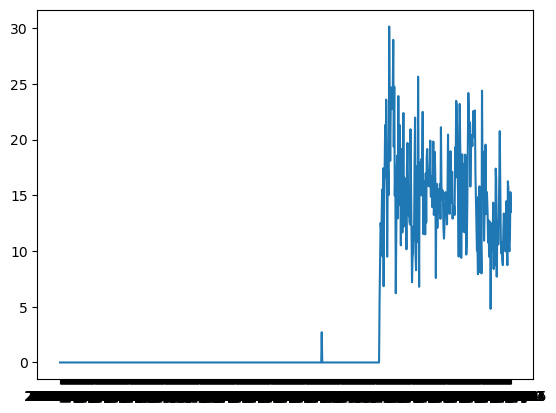

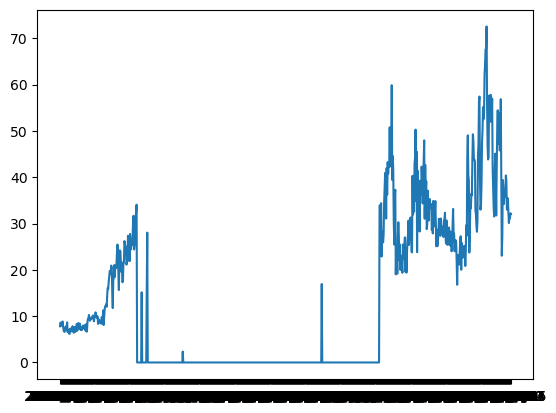

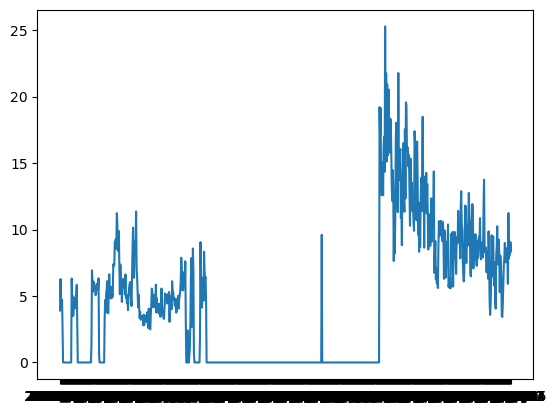

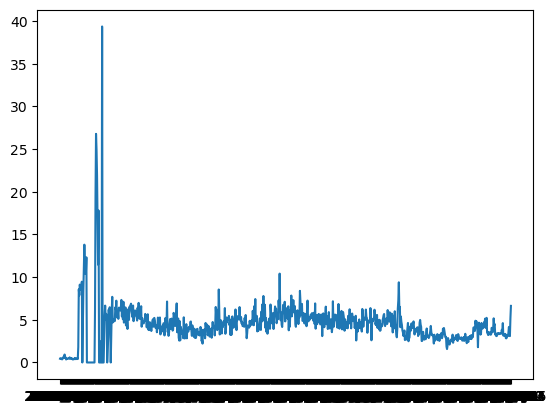

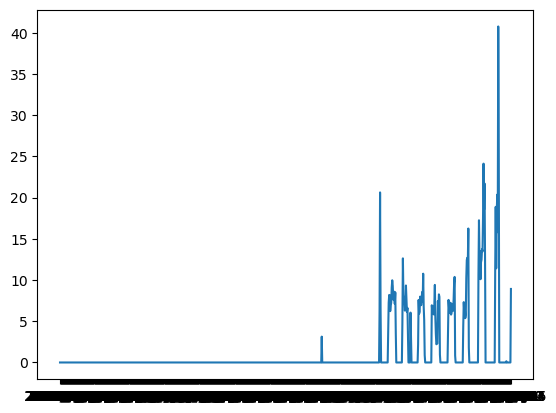

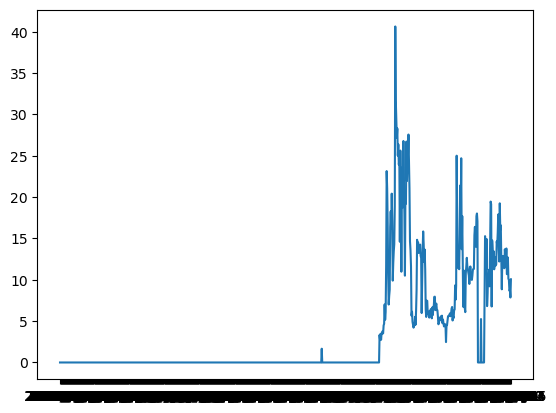

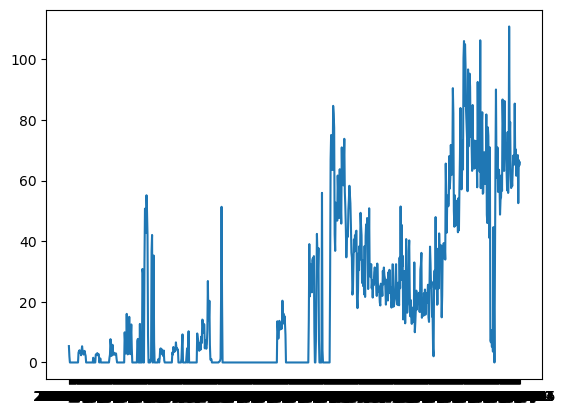

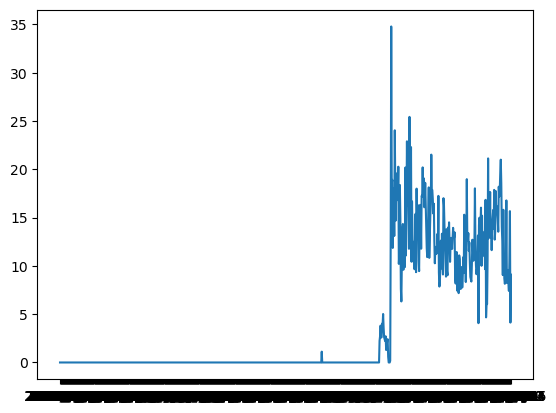

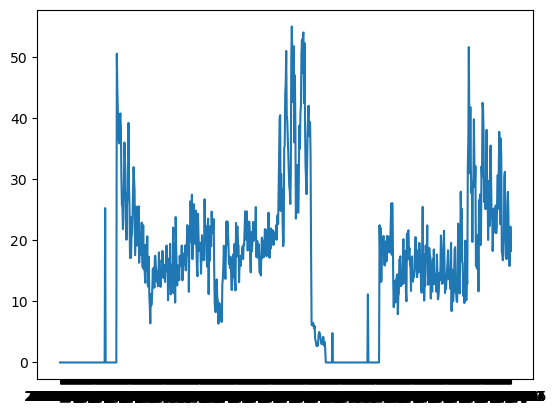

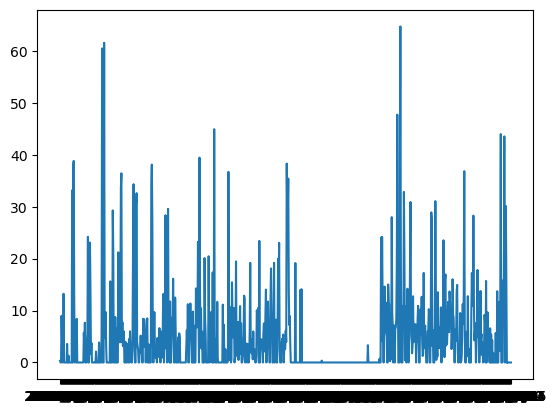

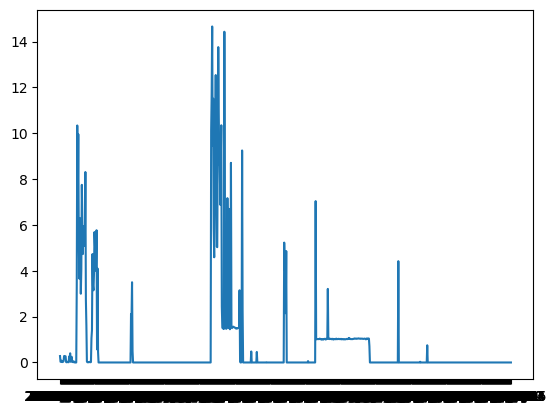

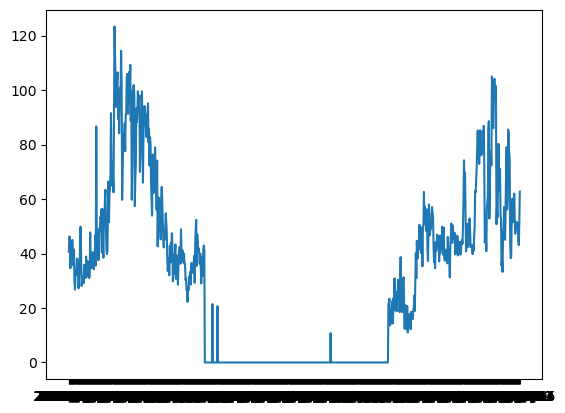

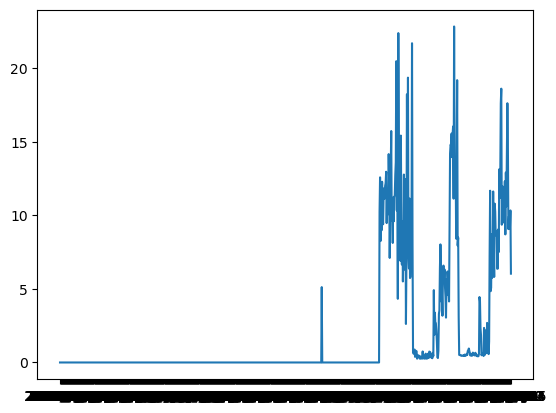

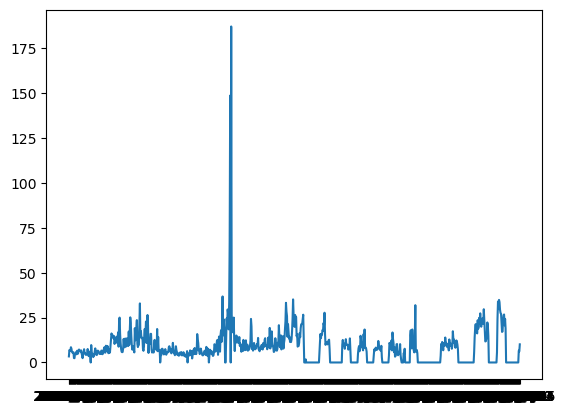

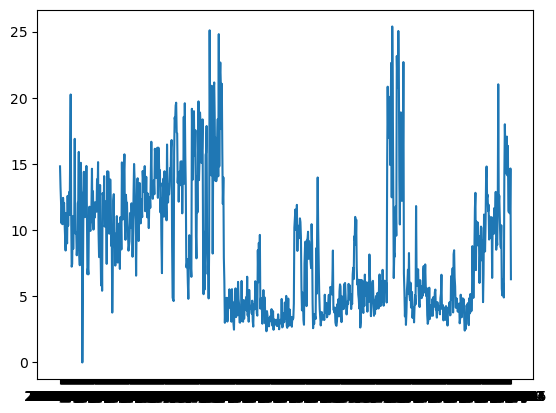

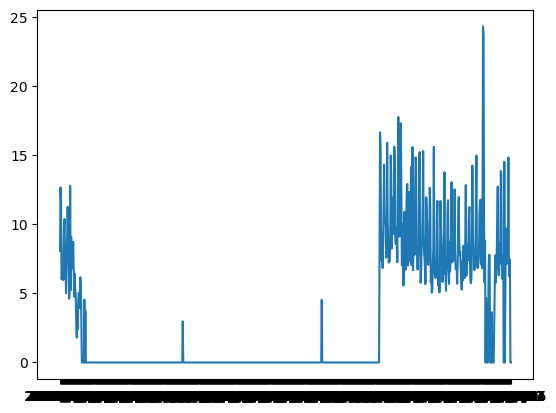

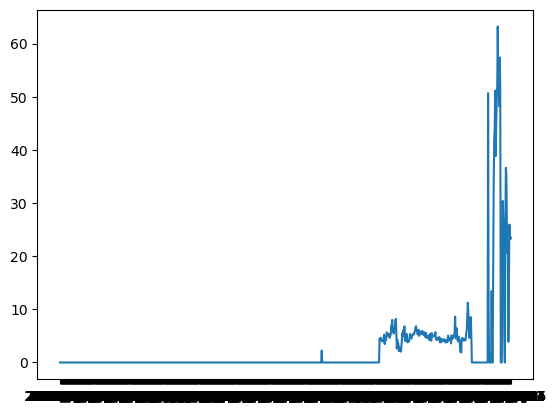

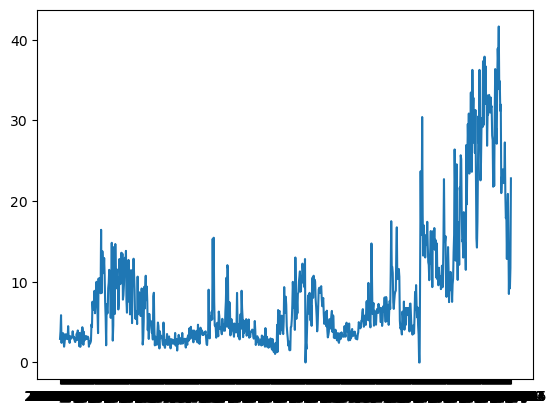

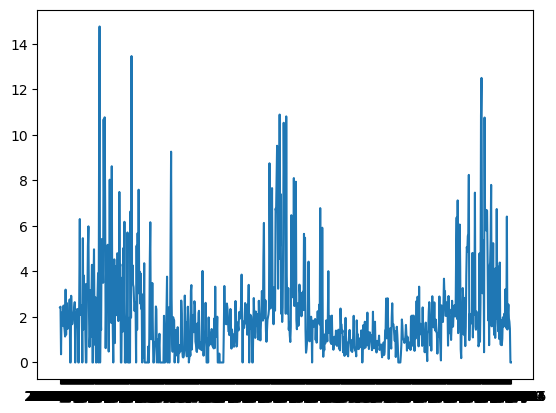

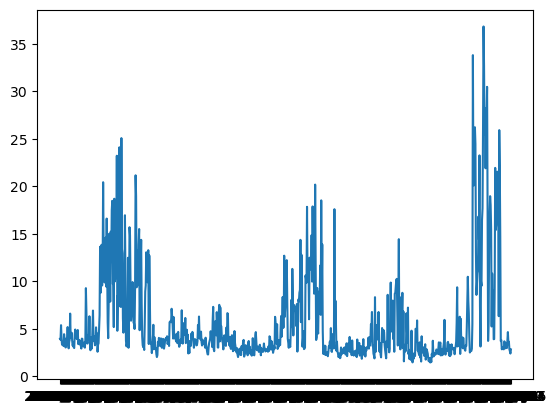

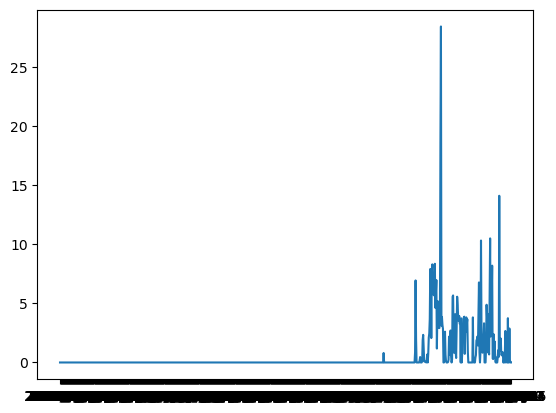

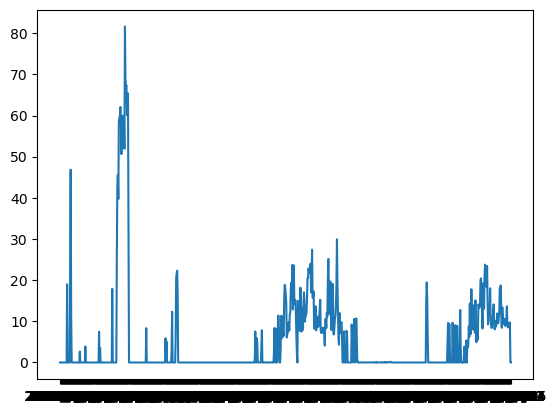

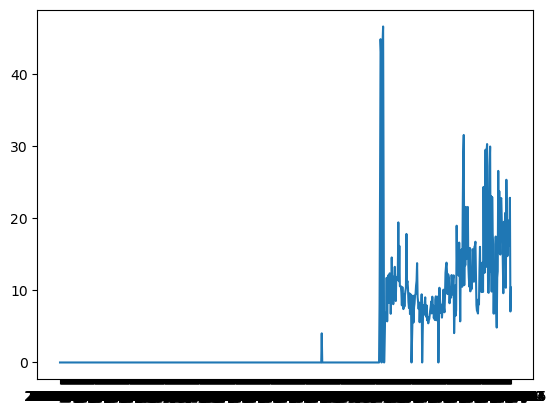

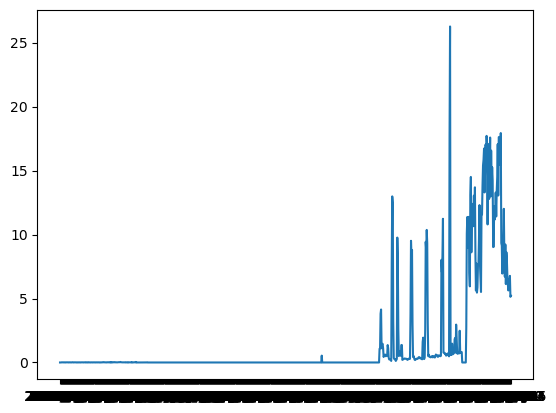

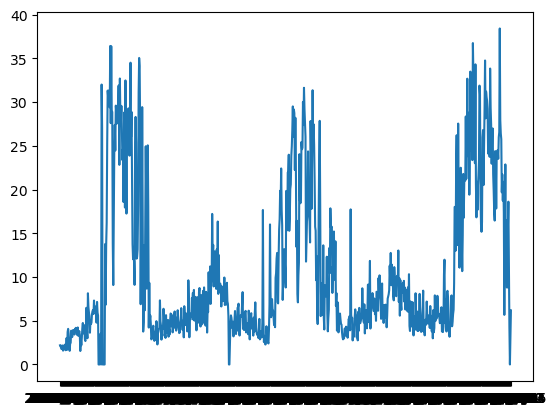

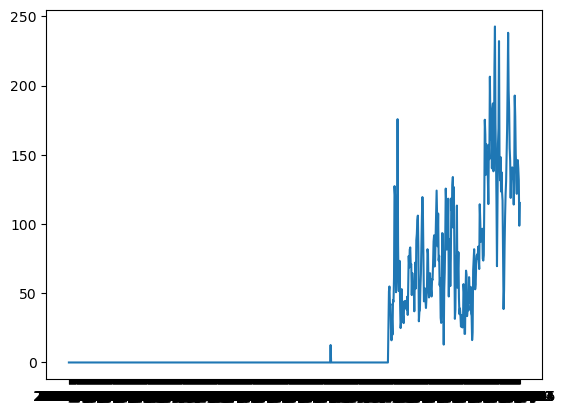

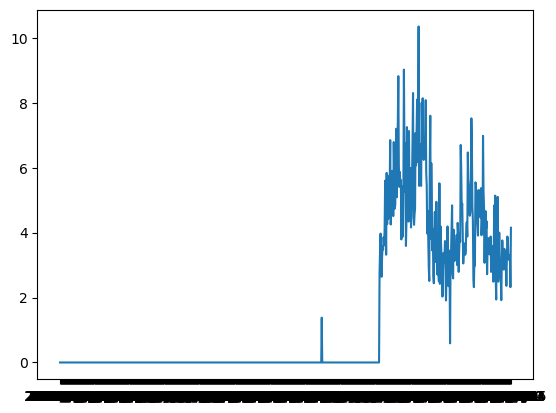

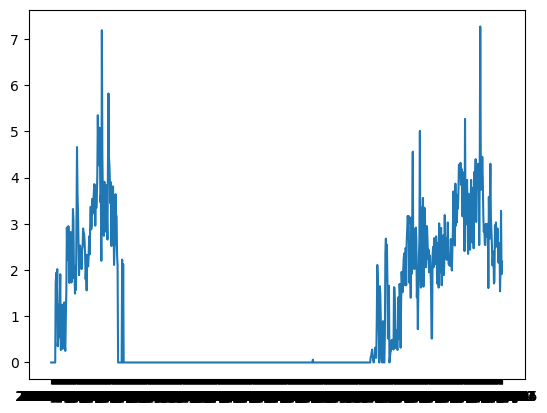

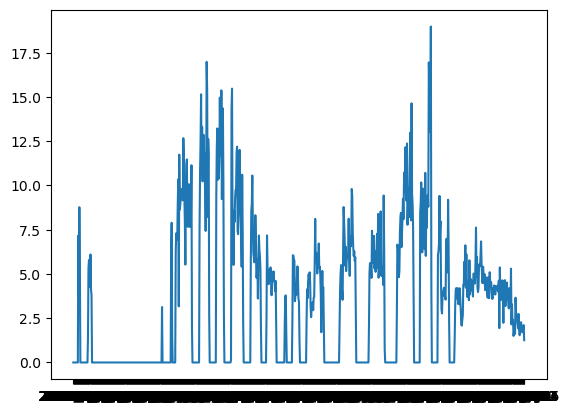

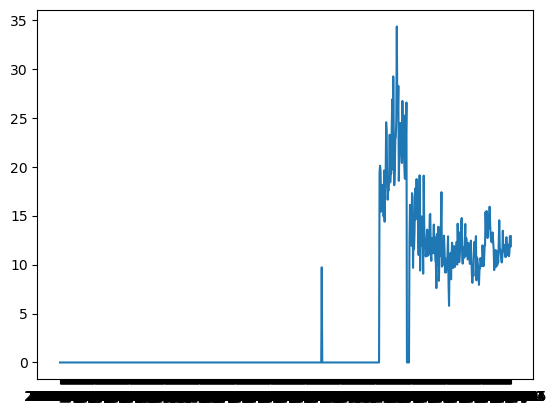

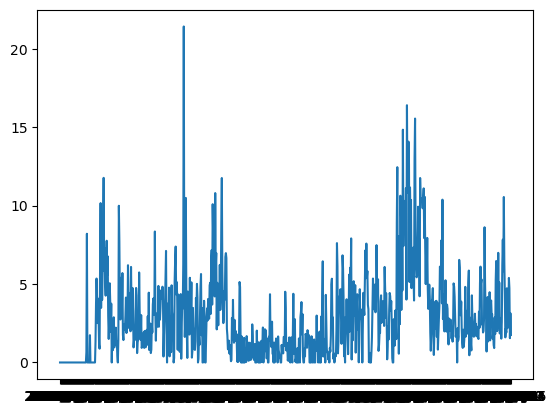

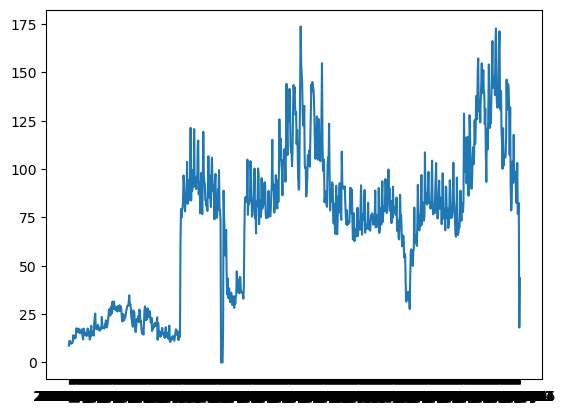

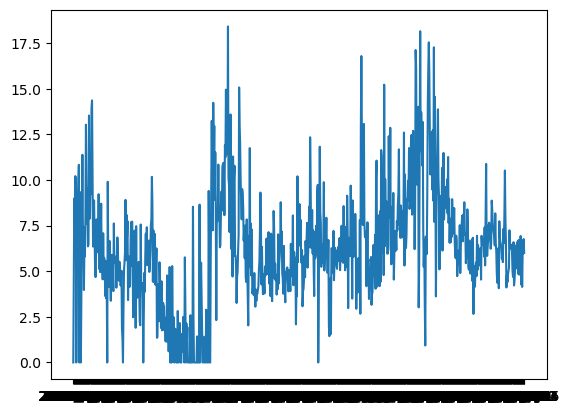

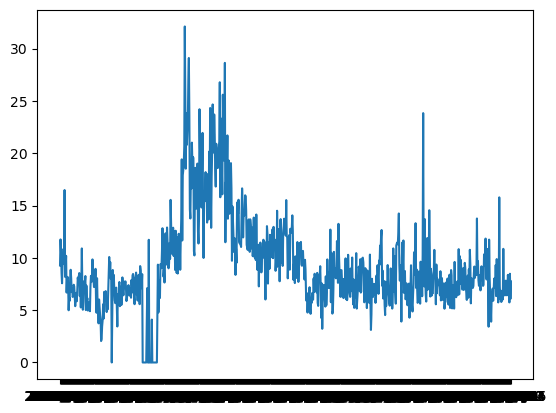

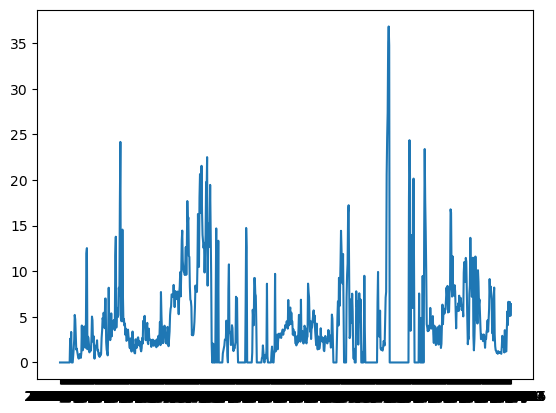

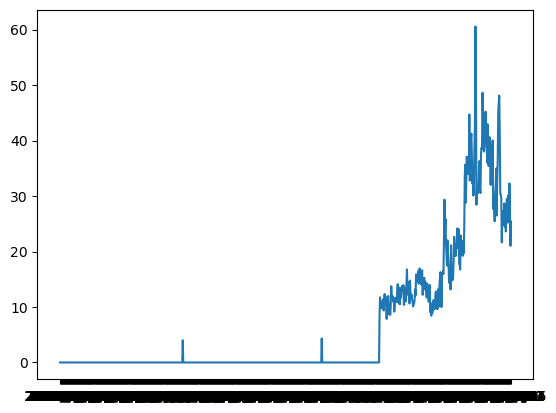

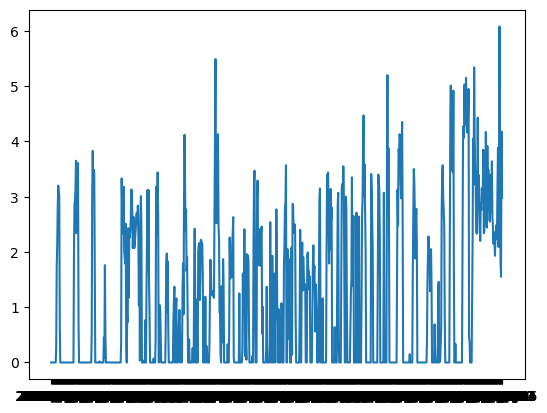

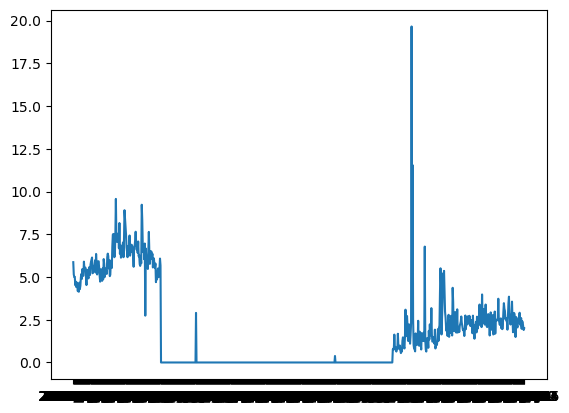

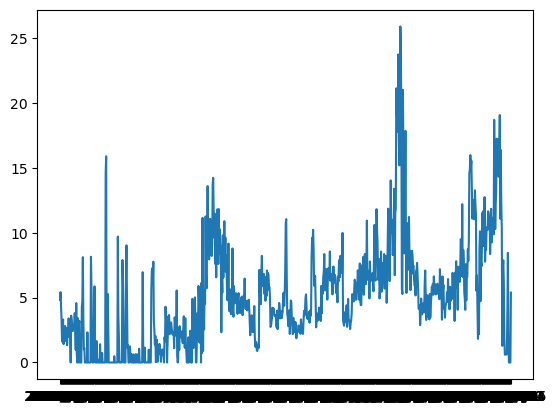

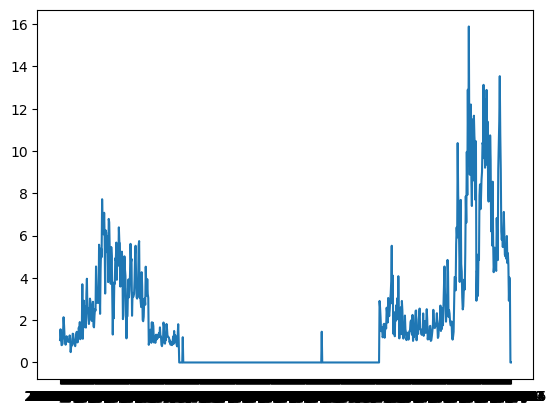

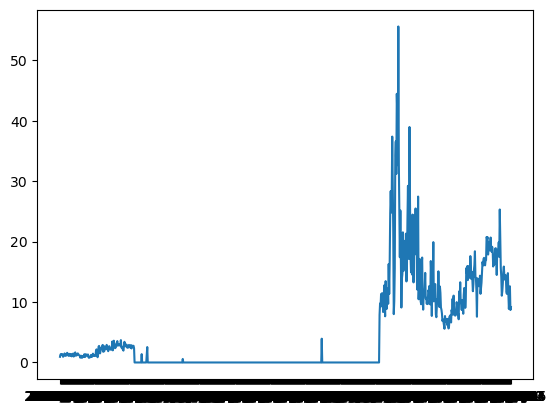

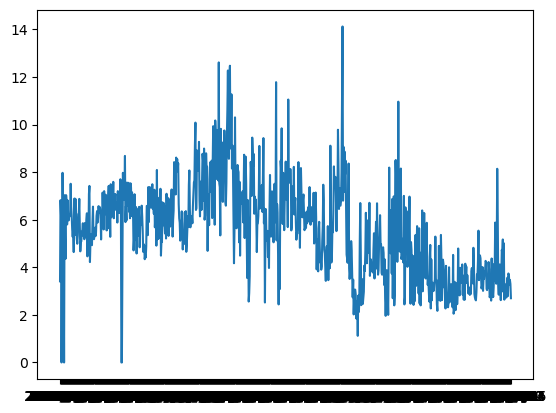

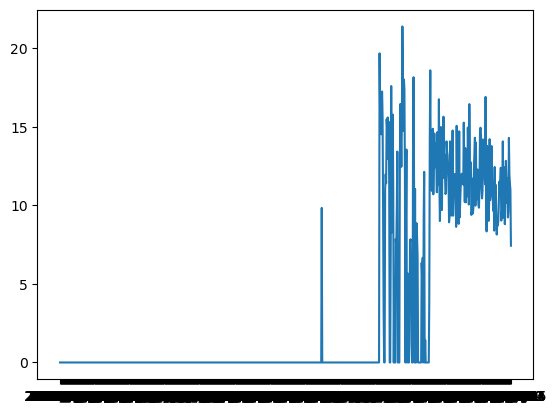

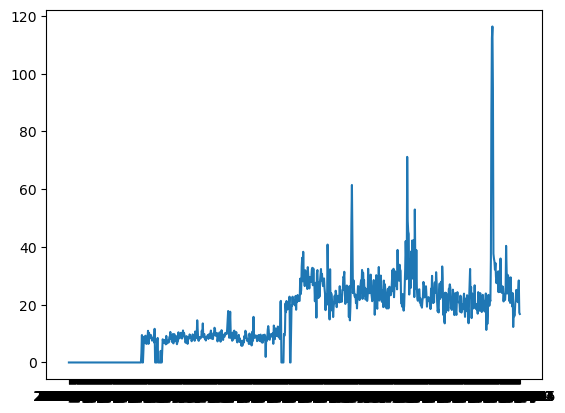

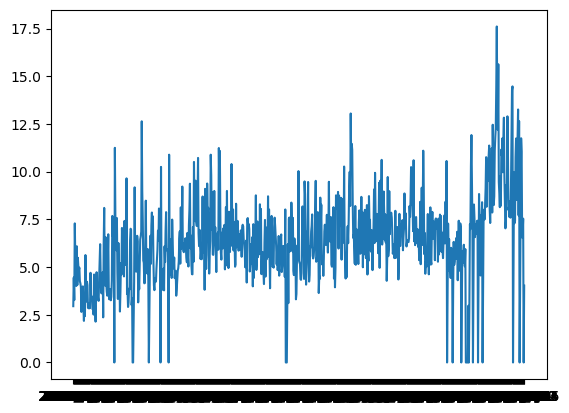

In [39]:
#c=0
#for i in l:
#    if(i<=70):
#        c+=1
#c
#df.iloc[4372].isnull().sum()
axes = plt.gca()
axes.set_ylim([0,250])
for i in range(250,300):
    plt.plot(l1,df1.iloc[i][l1])
    plt.show()

In [40]:


#df.isnull().sum(axis=1)
#may be theft in a period of time not always

In [41]:
#l1=[]
#for i in range(1000):
#    l=np.asarray(df1.iloc[i][lb]).tolist()
#    x=statistics.stdev(l)
#    y=statistics.mean(l)
#    l1.append(y+2*x)
    #df1.iloc[i][lb].apply(lambda t:y+2*x if t>y+2*x else t)

In [42]:
#df.iloc[1].isnull().sum()
#dfw=df[df["means"]>=1]
#l=df.columns.tolist()
#l[970]

In [43]:
#df1.iloc[1].describe()

In [44]:
#l=[df1.iloc[i].value_counts for i in range(42372)]
#df1.iloc[0].count(0)
#l=(df1==0).astype(int).sum(axis=1)

In [45]:
#l[250]

In [46]:
#df["means"]=df.mean(axis=1,skipna=True)
#la=df.mean(axis=1,skipna=True)
#l
#c=0
#for i in l:
#    if i<=15000:
#        c+=1
#c

In [47]:
#c=0
#for i in range(len(l)):
#    if l[i]<=200:
#        c+=1
#c
#df["mean"].shape
#df.fillna(df.means)

In [48]:
#for i in range(0,len(lb)):
#    l=np.asarray(df[lb[i]]).tolist()
    #l1=np.asarray(df[lb[i-1]]).tolist()
    #l2=np.asarray(df[lb[i+1]]).tolist()
#    l3=[]
#    for j in range(len(l)):
#        if math.isnan(l[j]):
#            l3.append(la[j])
#        else:
#            l3.append(l[j])
#    df[lb[i]]=l3

In [49]:
#df1["zero"]=l

In [50]:
#df2=df1[df1["zero"]<=400]

In [51]:
#df2["FLAG"].value_counts()

In [52]:
#len(X)
len(lbx)

1034

In [53]:
#l=np.asarray(df1.iloc[0][lb]).tolist()
#x=statistics.stdev(d)
#y=statistics.mean(l)
#d=df1.iloc[0][lb].apply(lambda t:y+2*x if t>y+2*x else t)
X=df1[lbx[500:]]
Y=df1["FLAG"]

In [54]:
X = X.fillna(0)

In [55]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20)

In [56]:
sm=SM(random_state=42)
#X_tr,Y_tr=sm.fit_sample(X_train,Y_train)
X_tr,Y_tr=sm.fit_resample(X_train,Y_train)

In [57]:
#model=RB()
#model.fit(X_trainpca,Y_train)
model=ET(n_estimators=10)
model.fit(X_tr,Y_tr)

ExtraTreesClassifier(n_estimators=10)

In [58]:
model.score(X_test,Y_test)

0.8874336283185841

In [59]:
l1=model.predict(X_test)
f1_score(Y_test,l1)

0.23434991974317818

In [60]:
Y_test=Y_test.tolist()

In [61]:
c=0
for i in range(len(l1)):
    if(Y_test[i])==0:
        c+=1
c

7723

In [62]:
c=0
for i in range(len(l1)):
    if l1[i]!=Y_test[i] and Y_test[i]==0:
        c+=1
print(c)

348


In [63]:
#pca = PCA(n_components=50).fit(X)
clf=KMeans(n_clusters=10)
clf.fit(X)

KMeans(n_clusters=10)

In [64]:
#df.iloc[4919].isnull().sum()
#X_pca= pca.transform(X)
centroids=clf.cluster_centers_
labels=clf.labels_
colors=["g.","r.","c.","b.","k.","o."]

In [65]:
t=clf.predict(X)

In [66]:
t=t.tolist()

In [67]:
c=0
l=[]
for i in range(len(t)):
    if Y[i]==1:
        l.append(t[i])

In [68]:
c=0
for i in l:
    if i==0:
        c+=1
c

3125

In [69]:
df1["labels"]=labels

C:\Users\shriy\AppData\Local\Temp\ipykernel_28008\1735104315.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1["labels"]=labels


In [70]:
X["labels"]=labels

C:\Users\shriy\AppData\Local\Temp\ipykernel_28008\2770898934.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X["labels"]=labels


In [71]:
X1=X[X["labels"]==0]

In [72]:
X1=X1.drop(["labels"],axis=1)

In [73]:
l=[]
for i in range(len(X1)):
    l.append(X1.iloc[i])

In [74]:
#c=0
#l1=[]
#for i in l:
#    for j in range(534):
#        c+=(i[j]-centroids[4][j])**2
#    c=np.sqrt(c)
#    l1.append(c)
#    c=0


In [75]:
t1=list((np.array(l) - np.array(centroids[0]))**2)

In [76]:
l2=[]
for i in t1:
    l2.append(np.sqrt(np.sum(i)))

In [77]:
mean=np.mean(l2)

In [78]:
Y1=Y[X["labels"]==0]

In [79]:
Y1=Y1.tolist()

In [80]:
c=0
l3=[]
for i in range(len(l2)):
    if Y1[i]==1:
        l3.append(l2[i])

In [81]:
#out of 3371  2716 with distance greater than 100.
X1["distance"]=l2

C:\Users\shriy\AppData\Local\Temp\ipykernel_28008\201246595.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X1["distance"]=l2


In [82]:
X1["theft"]=Y1

C:\Users\shriy\AppData\Local\Temp\ipykernel_28008\281732239.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X1["theft"]=Y1


In [83]:
X2=X1
len(l2)

40855

In [84]:
c=0
for i in range(len(l2)):
    if l2[i]<80 and Y1[i]==0:
        c+=1
c

6536

In [85]:
c=0
h=[]
for i in range(len(l2)):
    f=0
    if (l2[i]<=70 and Y1[i]==0) or (l2[i]>100 and Y1[i]==1):
        f=1
    if f==0:
        h.append(int(i))


In [86]:
if len(h) > 0 and len(h) < len(X2):
    X3=X2.drop(X2.index[h])
else:
    X3=X2


In [87]:
#Yf=X3["theft"]
#X3=X3.drop("theft",axis=1)
Ecd=X3["distance"]
X3=X3.drop("distance",axis=1)

In [88]:
lb=X3.columns.tolist()

In [89]:
l1=lb

In [90]:
Yf=X3["theft"]


In [91]:
Yf=Yf.tolist()

In [92]:
c=0
for i in Yf:
    if i==0:
        c+=1
c

3669

In [93]:
len(Yf)

6017

In [94]:
# debug removed


In [95]:
h=[]

In [96]:
#h=[[2,3],[4,5]]
#g=[3,4]
#t2=list(([np.array(i) for i in h] - np.array(g))**2)
#t2=list((np.array([2,3])-np.array([3,4])))

In [97]:
# debug removed


In [98]:
# debug removed


In [99]:
X3_clean = X3.drop(["theft"], axis=1) if "theft" in X3.columns else X3.copy()
X3_clean = X3_clean.fillna(0)
X_train,X_test,Y_train,Y_test=train_test_split(X3_clean, Yf, test_size=0.20)


In [100]:
sm=SM(random_state=42)
X_tr,Y_tr=sm.fit_resample(X_train,Y_train)


In [101]:
#statistics.stdev(l)
#X_trainpca.shape
#transformer = KernelPCA(n_components=50, kernel='linear')
#X_transformed =transformer.fit_transform(X_train)
X_train.shape

(4813, 534)

In [102]:
#l1=df1.isnull().sum(axis=1)
#l1=np.asarray(l1).tolist()

In [103]:
#model=RB()
#model.fit(X_trainpca,Y_train)
#model=MP(n_estimators=10)
model=ET()
model.fit(X_tr,Y_tr)

ExtraTreesClassifier()

In [104]:
model.score(X_train,Y_train)

1.0

In [105]:
#df.head()
ltr=model.predict(X_tr)

In [106]:
#sm=SM(random_state=42)
#X_ts,Y_ts=sm.fit_sample(X_test,Y_test)

In [107]:
c=0
for i in Y_test:
    if i==1:
        c+=1
c

434

In [108]:
#l=model.predict(X_ts)
model.score(X_test,Y_test)
#model.score(X_ts,Y_ts)
#f1_score(Y_ts,l)

0.9916943521594684

In [109]:
l1=model.predict(X_test)
f1_score(Y_test,l1)

0.9883449883449883

In [110]:
Y_test=np.asarray(Y_test).tolist()

In [111]:
c=0
for i in range(len(l1)):
    if(Y_test[i])==1:
        c+=1
c

434

In [112]:
c=0
for i in range(len(l1)):
    if l1[i]!=Y_test[i] and Y_test[i]==1:
        c+=1
print(c)

10


In [113]:
#len(Y_test)
#89 right predicted 284 wrong

In [114]:
c=0
for i in Y_test:
    if i==1:
        c+=1
c

434

In [115]:
#X_tr.shape
#dfa["null"]
#dfb["null"].value_counts()

In [116]:
#plt.scatter(dfa["null"],dfb["null"])

In [117]:
#df1=df1.drop("null",axis=1)

In [118]:
#df1[df1["FLAG"]==1].describe()

In [119]:
#l=Y_test

In [120]:
#Y_test----738 out of 8475 are 1.